In [4]:
import pandas as pd
from pyvi import ViTokenizer, ViPosTagger
import re
from collections import Counter
import matplotlib.pyplot as plt
from pyvi import ViTokenizer

c:\Users\NinhDB\tiki-sentiment-analytics\.venv\Lib\site-packages\pyvi\ViTokenizer.py:24: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  model = pickle.load(fin)


In [5]:
tiki_data = pd.read_csv(r'.\data_scraping\tiki_dataset.csv')
tiki_data.head()

,category,category_name,product_id,product_name,review_id,review,rating,label
0,1883,Nhà Cửa - Đời Sống,277833205,Cốc giữ nhiệt inox 304 Elmich EL8384 dung tích...,20141063,SP đẹp như hình,5,Cực kì hài lòng
1,1883,Nhà Cửa - Đời Sống,277776638,Chảo chống dính Elmich EL5972,20199611,Giao hàng rất nhanh. Đang cần gấp để nấu. Nhưn...,2,Không hài lòng
2,1883,Nhà Cửa - Đời Sống,277776638,Chảo chống dính Elmich EL5972,20197992,"Chảo bị vênh lòng, cao ở giữa, trũng xung quan...",1,Rất không hài lòng
3,1883,Nhà Cửa - Đời Sống,277776638,Chảo chống dính Elmich EL5972,20131003,Hàng dùng tốt,5,Cực kì hài lòng
4,1883,Nhà Cửa - Đời Sống,277740594,Cốc giữ nhiệt inox 304 Elmich 2248380 dung tíc...,20200613,"Bình ok, giá cả hợp lý, màu tím bên ngoài thiê...",5,Cực kì hài lòng


In [6]:
tiki_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84669 entries, 0 to 84668
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   category       84669 non-null  int64 
 1   category_name  84669 non-null  object
 2   product_id     84669 non-null  int64 
 3   product_name   84669 non-null  object
 4   review_id      84669 non-null  int64 
 5   review         84668 non-null  object
 6   rating         84669 non-null  int64 
 7   label          84667 non-null  object
dtypes: int64(4), object(4)
memory usage: 5.2+ MB


In [7]:
tiki_data.dropna(inplace=True)

In [8]:
tiki_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 84666 entries, 0 to 84668
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   category       84666 non-null  int64 
 1   category_name  84666 non-null  object
 2   product_id     84666 non-null  int64 
 3   product_name   84666 non-null  object
 4   review_id      84666 non-null  int64 
 5   review         84666 non-null  object
 6   rating         84666 non-null  int64 
 7   label          84666 non-null  object
dtypes: int64(4), object(4)
memory usage: 5.8+ MB


In [9]:
stopwords = [
"a lô","ai","ai đó","alô","anh","ba","bao giờ","bao nhiêu","bây giờ","bên","bạn","bản thân","bất cứ","bất kỳ","bằng","bị","bởi","bởi vì","cho","cho nên","cho đến","chung","chúng ta","chúng tôi","chưa","chỉ","chị","các","cách","cái","câu hỏi","còn","có","có thể","cùng","cũng","của","cứ","do","do đó","dù","dù sao","dùng","em","giờ","gì","gần","gồm","hay","hoặc","hãy","hơn","hết","họ","khi","khoảng","khác","kể","là","làm","lên","lúc","lại","lấy","mà","mình","mọi","mỗi","một","mới","nay","ngay","nghe","nghĩ","ngoài","ngày","người","nhau","nhà","như","nhưng","những","nào","này","nên","nếu","nói","nơi","nữa","qua","quá","ra","rằng","rồi","sao","sau","so với","sẽ","số","sự","tại","theo","thì","thế","thôi","thường","thực ra","tin","trong","trên","trước","tuy","tuy nhiên","từ","tự","và","vài","vào","vì","vì vậy","với","vừa","về","vậy","xem","xin","yêu cầu","đang","đâu","đây","đã","đó","được","đến","đều","để","đối với","đủ","ở"
]

In [12]:
slang_dict = {
    "ko": "không",
    "k": "không",
    "dc": "được",
    "sp": "sản phẩm",
    "ok": "tốt",
    "shop": "cửa hàng",
    "ship": "giao hàng"
}
def normalize_slang(text):
    words = text.split()
    words = [slang_dict.get(word, word) for word in words]
    return " ".join(words)

def normalize_numbers(text): 
    mapping = {
        '4': 'bốn', 
        '5': 'năm' 
    } 
    words = text.split() 
    words = [mapping.get(word, word) for word in words] 
    return " ".join(words) 

In [13]:
preprocessing_reviews = []
for review in tiki_data['review']:
    ''''''
    # remove \n characters in the middle and leading/trailing spaces
    review = review.strip().replace("\n", " ")
    # convert to lower case
    review = review.lower()
    # remove special character
    review = re.sub(r"[^\w\s]", " ", review)
    # remove extra spaces
    review = re.sub(r"\s+", " ", review)
    # normalize lengthening
    review = re.sub(r"(.)\1{2,}", r"\1", review)
    review = normalize_slang(review)
    review = normalize_numbers(review) 
    preprocessing_reviews.append(ViTokenizer.tokenize(review))

preprocessing_reviews

['sản_phẩm đẹp như hình',
 'giao hàng rất nhanh đang cần gấp để nấu nhưng vừa mở ra thất_vọng vô_cùng bị móp cửa_hàng vó kiểm_tra trước khi giao không vậy đổi trả mất_công nên đành chịu đã hiểu vì_sao giảm_giá shock',
 'chảo bị vênh lòng cao ở giữa trũng xung_quanh nên rán không đều',
 'hàng dùng tốt',
 'bình tốt giá_cả hợp_lý màu tím bên ngoài thiên về màu tím tro nhạt hơn trong hình',
 'giao hàng nhanh cẩn_thận nhưng màu_sắc hơi tối so với giới_thiệu nhìn khá cũ bình giữ nóng được tầm bốn năm tiếng thôi',
 'nồi đẹp nhưng nấu nc 45p vẫn không sôi chỉ sủi tăm cửa_hàng xử_lý dùm',
 'nồi dày_dặn đẹp và khá to nha nên mua dùng thích đấy',
 'minh rất thích khi nhìn thay so',
 'mùi dễ_chịu nhưng trong hũ còn nhiều vụn thảo_dược không nằm trong bọc lưới nên khi hít sẽ hít luôn vào mũi khá khó_chịu nhưng không đáng_kể',
 'không tặng kèm ống hút inox như mô_tả',
 'combo nồi chảo đẹp xuất_sắc_màu nhìn phát ưng luôn vừa nấu_nướng vừa decor bếp không có chỗ nào chê',
 'giao hàng nhanh đóng_gói cẩ

In [14]:
remove_stopwords = []
for review in preprocessing_reviews:
    list = review.strip().split()
    words = []
    for word in list:
        if word not in stopwords:
            words.append(word)
    remove_stopwords.append(" ".join(words))

In [15]:
remove_stopwords

['sản_phẩm đẹp hình',
 'giao hàng rất nhanh cần gấp nấu mở thất_vọng vô_cùng móp cửa_hàng vó kiểm_tra giao không đổi trả mất_công đành chịu hiểu vì_sao giảm_giá shock',
 'chảo vênh lòng cao giữa trũng xung_quanh rán không',
 'hàng tốt',
 'bình tốt giá_cả hợp_lý màu tím thiên màu tím tro nhạt hình',
 'giao hàng nhanh cẩn_thận màu_sắc hơi tối so giới_thiệu nhìn khá cũ bình giữ nóng tầm bốn năm tiếng',
 'nồi đẹp nấu nc 45p vẫn không sôi sủi tăm cửa_hàng xử_lý dùm',
 'nồi dày_dặn đẹp khá to nha mua thích đấy',
 'minh rất thích nhìn thay so',
 'mùi dễ_chịu hũ nhiều vụn thảo_dược không nằm bọc lưới hít hít luôn mũi khá khó_chịu không đáng_kể',
 'không tặng kèm ống hút inox mô_tả',
 'combo nồi chảo đẹp xuất_sắc_màu nhìn phát ưng luôn nấu_nướng decor bếp không chỗ chê',
 'giao hàng nhanh đóng_gói cẩn_thận sản_phẩm mua giá tốt',
 'đẹp mua giá giảm tốt lắm màu xinh cực',
 'sản_phẩm mô_tả',
 'ghịgfdscbjif huế mộng buụhgđvbjo',
 'bình giữ nhiệt lâu 7tiếng cháo vẫn bỏng phải chờ 20phút nguội',
 'đẹ

In [16]:
tiki_data['review'] = remove_stopwords

In [17]:
tiki_data.duplicated().any()

np.True_

In [18]:
tiki_data.drop_duplicates(inplace=True)

In [19]:
all_words = []
for review in tiki_data['review']:
    words = review.strip().split()
    for word in words: all_words.append(word)
word_counts = Counter(all_words)

In [20]:
word_counts_df = pd.DataFrame(word_counts.items(), columns=['word', 'frequency'])
word_counts_df = word_counts_df.sort_values(by='frequency', ascending=False)
word_counts_df.head(50)

,word,frequency
35,tốt,33067
4,hàng,29390
3,giao,21487
17,không,20356
6,nhanh,15988
0,sản_phẩm,15469
5,rất,15157
71,mua,11630
1,đẹp,8607
125,chất_lượng,7714


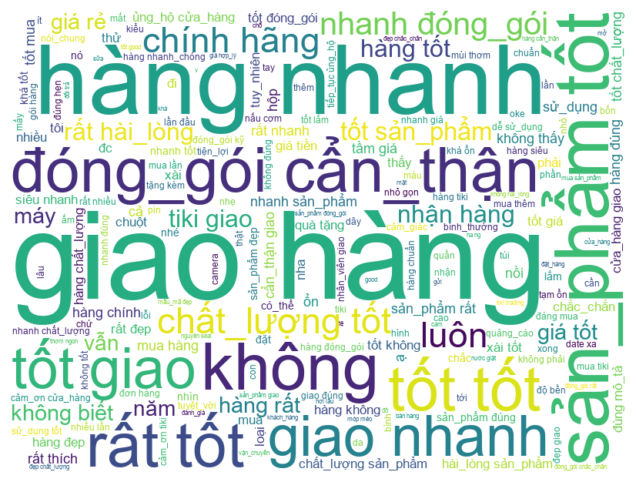

In [22]:
from wordcloud import WordCloud

text = " ".join(tiki_data['review'])

wordcloud = WordCloud (
    width=800,
    height=600,
    background_color='white',
    font_path='arial.ttf'
).generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

In [23]:
tiki_data['target'] = tiki_data['rating'].apply(lambda x: 1 if x >= 4 else 0)

In [24]:
tiki_data

,category,category_name,product_id,product_name,review_id,review,rating,label,target
0,1883,Nhà Cửa - Đời Sống,277833205,Cốc giữ nhiệt inox 304 Elmich EL8384 dung tích...,20141063,sản_phẩm đẹp hình,5,Cực kì hài lòng,1
1,1883,Nhà Cửa - Đời Sống,277776638,Chảo chống dính Elmich EL5972,20199611,giao hàng rất nhanh cần gấp nấu mở thất_vọng v...,2,Không hài lòng,0
2,1883,Nhà Cửa - Đời Sống,277776638,Chảo chống dính Elmich EL5972,20197992,chảo vênh lòng cao giữa trũng xung_quanh rán k...,1,Rất không hài lòng,0
3,1883,Nhà Cửa - Đời Sống,277776638,Chảo chống dính Elmich EL5972,20131003,hàng tốt,5,Cực kì hài lòng,1
4,1883,Nhà Cửa - Đời Sống,277740594,Cốc giữ nhiệt inox 304 Elmich 2248380 dung tíc...,20200613,bình tốt giá_cả hợp_lý màu tím thiên màu tím t...,5,Cực kì hài lòng,1
...,...,...,...,...,...,...,...,...,...
84664,15078,Chăm sóc nhà cửa,463748,Chất Làm Sạch Lồng Giặt Mao Bao Ion Bạc Nâng C...,551997,minh nhận gói maobao khuyến_mãi 300g bột_giặt ...,5,Sản phẩm tốt,1
84665,15078,Chăm sóc nhà cửa,463748,Chất Làm Sạch Lồng Giặt Mao Bao Ion Bạc Nâng C...,408899,máy_giặt sử_dụng 10 năm nhiều giặt đồ cảm_giác...,5,Sản phẩm rất hiệu quả,1
84666,15078,Chăm sóc nhà cửa,463748,Chất Làm Sạch Lồng Giặt Mao Bao Ion Bạc Nâng C...,376890,xài máy_giặt bẩn nhiều luôn nhìn thấy sợ không...,5,Hàng tốt,1
84667,15078,Chăm sóc nhà cửa,463748,Chất Làm Sạch Lồng Giặt Mao Bao Ion Bạc Nâng C...,414854,gia_đình rất tin_dùng sản_phẩm_chất sạch lồng ...,5,Tốt,1


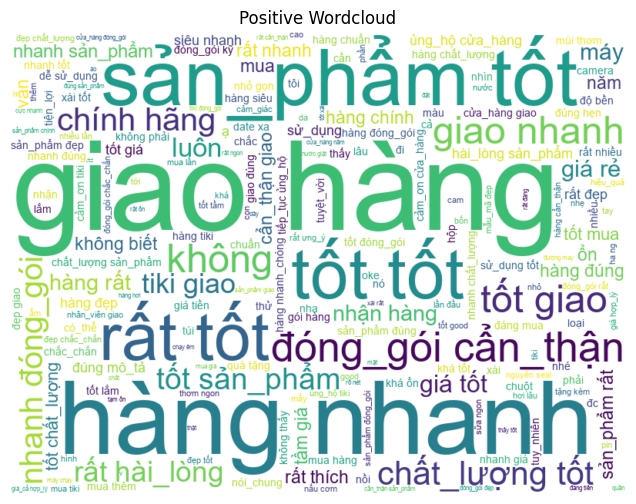

In [25]:
positive_text = " ".join(tiki_data[tiki_data['target'] == 1]['review'])

positive_wordcloud = WordCloud (
    width=800,
    height=600,
    background_color="white",
    font_path="arial.ttf"
).generate(positive_text)

plt.figure(figsize=(12,6))
plt.imshow(positive_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Positive Wordcloud")
plt.show()

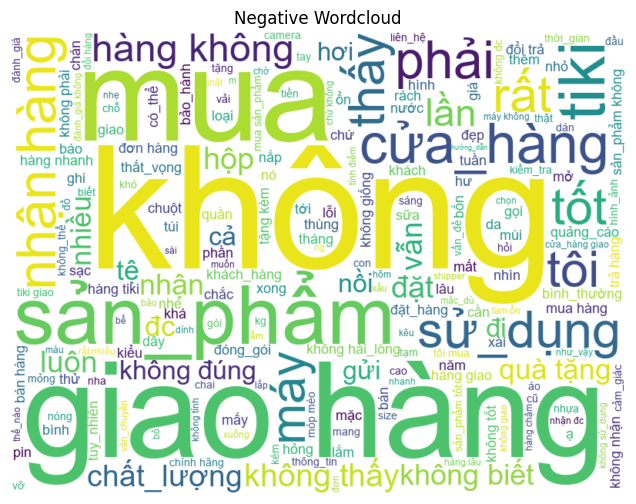

In [26]:
negative_text = " ".join(tiki_data[tiki_data['target'] == 0]['review'])

negative_wordcloud = WordCloud (
    width=800,
    height=600,
    background_color="white",
    font_path="arial.ttf"
).generate(negative_text)

plt.figure(figsize=(12,6))
plt.imshow(negative_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Negative Wordcloud")
plt.show()

In [27]:
tiki_data

,category,category_name,product_id,product_name,review_id,review,rating,label,target
0,1883,Nhà Cửa - Đời Sống,277833205,Cốc giữ nhiệt inox 304 Elmich EL8384 dung tích...,20141063,sản_phẩm đẹp hình,5,Cực kì hài lòng,1
1,1883,Nhà Cửa - Đời Sống,277776638,Chảo chống dính Elmich EL5972,20199611,giao hàng rất nhanh cần gấp nấu mở thất_vọng v...,2,Không hài lòng,0
2,1883,Nhà Cửa - Đời Sống,277776638,Chảo chống dính Elmich EL5972,20197992,chảo vênh lòng cao giữa trũng xung_quanh rán k...,1,Rất không hài lòng,0
3,1883,Nhà Cửa - Đời Sống,277776638,Chảo chống dính Elmich EL5972,20131003,hàng tốt,5,Cực kì hài lòng,1
4,1883,Nhà Cửa - Đời Sống,277740594,Cốc giữ nhiệt inox 304 Elmich 2248380 dung tíc...,20200613,bình tốt giá_cả hợp_lý màu tím thiên màu tím t...,5,Cực kì hài lòng,1
...,...,...,...,...,...,...,...,...,...
84664,15078,Chăm sóc nhà cửa,463748,Chất Làm Sạch Lồng Giặt Mao Bao Ion Bạc Nâng C...,551997,minh nhận gói maobao khuyến_mãi 300g bột_giặt ...,5,Sản phẩm tốt,1
84665,15078,Chăm sóc nhà cửa,463748,Chất Làm Sạch Lồng Giặt Mao Bao Ion Bạc Nâng C...,408899,máy_giặt sử_dụng 10 năm nhiều giặt đồ cảm_giác...,5,Sản phẩm rất hiệu quả,1
84666,15078,Chăm sóc nhà cửa,463748,Chất Làm Sạch Lồng Giặt Mao Bao Ion Bạc Nâng C...,376890,xài máy_giặt bẩn nhiều luôn nhìn thấy sợ không...,5,Hàng tốt,1
84667,15078,Chăm sóc nhà cửa,463748,Chất Làm Sạch Lồng Giặt Mao Bao Ion Bạc Nâng C...,414854,gia_đình rất tin_dùng sản_phẩm_chất sạch lồng ...,5,Tốt,1


In [28]:
tiki_data.reset_index(inplace=True)

In [29]:
tiki_data.drop(columns='index', inplace=True)

In [30]:
tiki_data

,category,category_name,product_id,product_name,review_id,review,rating,label,target
0,1883,Nhà Cửa - Đời Sống,277833205,Cốc giữ nhiệt inox 304 Elmich EL8384 dung tích...,20141063,sản_phẩm đẹp hình,5,Cực kì hài lòng,1
1,1883,Nhà Cửa - Đời Sống,277776638,Chảo chống dính Elmich EL5972,20199611,giao hàng rất nhanh cần gấp nấu mở thất_vọng v...,2,Không hài lòng,0
2,1883,Nhà Cửa - Đời Sống,277776638,Chảo chống dính Elmich EL5972,20197992,chảo vênh lòng cao giữa trũng xung_quanh rán k...,1,Rất không hài lòng,0
3,1883,Nhà Cửa - Đời Sống,277776638,Chảo chống dính Elmich EL5972,20131003,hàng tốt,5,Cực kì hài lòng,1
4,1883,Nhà Cửa - Đời Sống,277740594,Cốc giữ nhiệt inox 304 Elmich 2248380 dung tíc...,20200613,bình tốt giá_cả hợp_lý màu tím thiên màu tím t...,5,Cực kì hài lòng,1
...,...,...,...,...,...,...,...,...,...
84658,15078,Chăm sóc nhà cửa,463748,Chất Làm Sạch Lồng Giặt Mao Bao Ion Bạc Nâng C...,551997,minh nhận gói maobao khuyến_mãi 300g bột_giặt ...,5,Sản phẩm tốt,1
84659,15078,Chăm sóc nhà cửa,463748,Chất Làm Sạch Lồng Giặt Mao Bao Ion Bạc Nâng C...,408899,máy_giặt sử_dụng 10 năm nhiều giặt đồ cảm_giác...,5,Sản phẩm rất hiệu quả,1
84660,15078,Chăm sóc nhà cửa,463748,Chất Làm Sạch Lồng Giặt Mao Bao Ion Bạc Nâng C...,376890,xài máy_giặt bẩn nhiều luôn nhìn thấy sợ không...,5,Hàng tốt,1
84661,15078,Chăm sóc nhà cửa,463748,Chất Làm Sạch Lồng Giặt Mao Bao Ion Bạc Nâng C...,414854,gia_đình rất tin_dùng sản_phẩm_chất sạch lồng ...,5,Tốt,1


In [31]:
dataset = tiki_data[['review', 'target']]

In [32]:
dataset.duplicated().any()

np.True_

In [33]:
dataset = dataset.drop_duplicates()

In [34]:
dataset[dataset['review'] == ""]

,review,target
45,,1
1649,,0


In [35]:
dataset.drop(index=45, inplace=True)

In [36]:
dataset.drop(index=1649, inplace=True)

In [37]:
dataset.to_csv("./data.csv", index=False, encoding="utf-8-sig")